In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from scipy.stats import randint, uniform

In [2]:
# Load data
with open('../Preprocessing/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('../Preprocessing/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('../Preprocessing/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('../Preprocessing/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

In [3]:
# Define parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

In [4]:
# Initialize base model
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

In [5]:
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("\nStarting Randomized Search...")
random_search.fit(X_train, y_train)

print(f"\nBest parameters from Randomized Search:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation AUC: {random_search.best_score_:.4f}")


Starting Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters from Randomized Search:
  bootstrap: False
  criterion: entropy
  max_depth: 30
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 9
  n_estimators: 227

Best cross-validation AUC: 0.9855


In [6]:
# Evaluate on test set
y_test_pred_random = random_search.predict(X_test)
y_test_prob_random = random_search.predict_proba(X_test)[:, 1]
test_auc_random = roc_auc_score(y_test, y_test_prob_random)
test_acc_random = accuracy_score(y_test, y_test_pred_random)

print(f"Test Accuracy: {test_acc_random:.4f}")
print(f"Test AUC: {test_auc_random:.4f}")

Test Accuracy: 0.9643
Test AUC: 0.9966


In [7]:
# Create fine-tuned parameter grid around best parameters
best_params = random_search.best_params_

# Define narrow ranges around best parameters
param_grid = {
    'n_estimators': [
        max(100, best_params['n_estimators'] - 50),
        best_params['n_estimators'],
        best_params['n_estimators'] + 50
    ],
    'max_depth': [
        best_params['max_depth'] - 5 if best_params['max_depth'] and best_params['max_depth'] > 5 else best_params['max_depth'],
        best_params['max_depth'],
        best_params['max_depth'] + 5 if best_params['max_depth'] else None
    ] if best_params['max_depth'] else [None, 20, 30],
    'min_samples_split': [
        max(2, best_params['min_samples_split'] - 2),
        best_params['min_samples_split'],
        best_params['min_samples_split'] + 2
    ],
    'min_samples_leaf': [
        max(1, best_params['min_samples_leaf'] - 1),
        best_params['min_samples_leaf'],
        best_params['min_samples_leaf'] + 1
    ],
    'max_features': [best_params['max_features']],
    'bootstrap': [best_params['bootstrap']]
}

In [8]:
# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        criterion=best_params.get('criterion', 'gini')
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

print("\nStarting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters from Grid Search:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")


Starting Grid Search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters from Grid Search:
  bootstrap: False
  max_depth: 25
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 7
  n_estimators: 227

Best cross-validation AUC: 0.9858


In [9]:
# Final model evaluation

final_model = grid_search.best_estimator_

# Predictions
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)
y_train_prob = final_model.predict_proba(X_train)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nPerformance Metrics")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_test_pred,
                          target_names=['No Attrition', 'Attrition']))


Performance Metrics
Training Accuracy: 1.0000
Test Accuracy: 0.9610
Training AUC: 1.0000
Test AUC: 0.9973

Classification Report
              precision    recall  f1-score   support

No Attrition       0.99      0.94      0.96       312
   Attrition       0.93      0.99      0.96       277

    accuracy                           0.96       589
   macro avg       0.96      0.96      0.96       589
weighted avg       0.96      0.96      0.96       589



In [10]:
# Cross-validation score
cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\n--- Cross-Validation Scores ---")
print(f"CV AUC Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



--- Cross-Validation Scores ---
CV AUC Scores: [0.9915317  0.99687732 0.98967926 0.98618888 0.96481876]
Mean CV AUC: 0.9858 (+/- 0.0221)


Text(0.5, 500.7222222222223, 'Predicted')

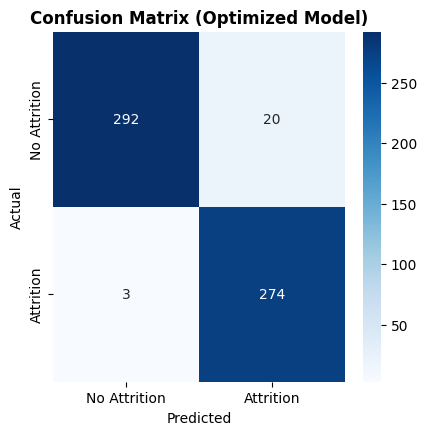

In [11]:
# Visualizations
fig = plt.figure(figsize=(16, 10))

#Confusion Matrix
plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix (Optimized Model)', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

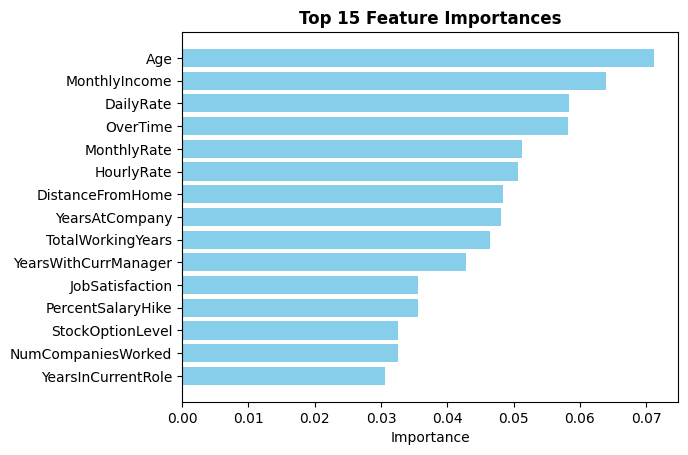

In [12]:
#Feature Importance
plt.subplot(1, 1, 1)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='skyblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()


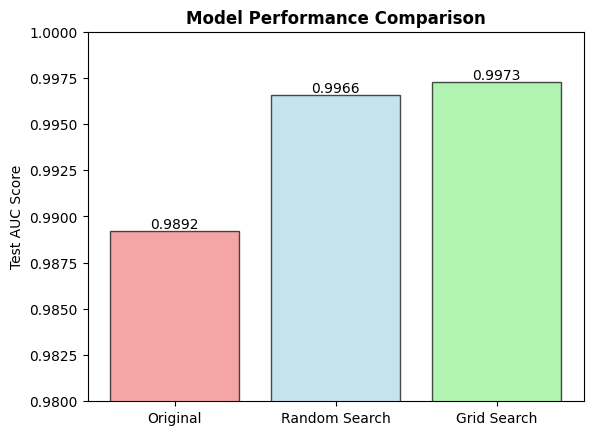

In [13]:
# Model Comparison
plt.subplot(1, 1, 1)
models = ['Original', 'Random Search', 'Grid Search']
test_aucs = [0.9892, test_auc_random, test_auc]
colors = ['lightcoral', 'lightblue', 'lightgreen']
bars = plt.bar(models, test_aucs, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Test AUC Score')
plt.title('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.ylim([0.98, 1.0])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom')


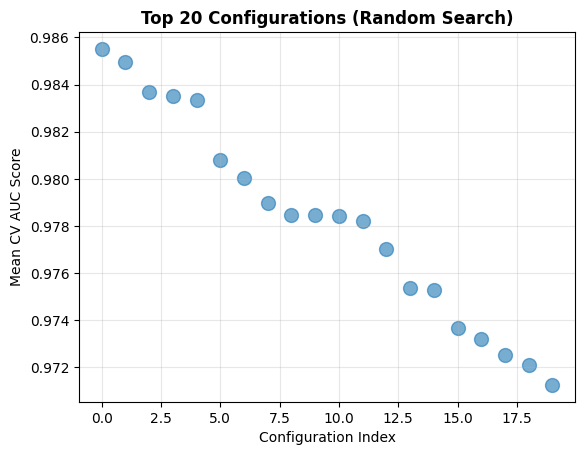

In [14]:
# Hyperparameter Tuning Results
plt.subplot(1, 1, 1)
results_df = pd.DataFrame(random_search.cv_results_)
top_20 = results_df.nsmallest(20, 'rank_test_score')
plt.scatter(range(len(top_20)), top_20['mean_test_score'], alpha=0.6, s=100)
plt.xlabel('Configuration Index')
plt.ylabel('Mean CV AUC Score')
plt.title('Top 20 Configurations (Random Search)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

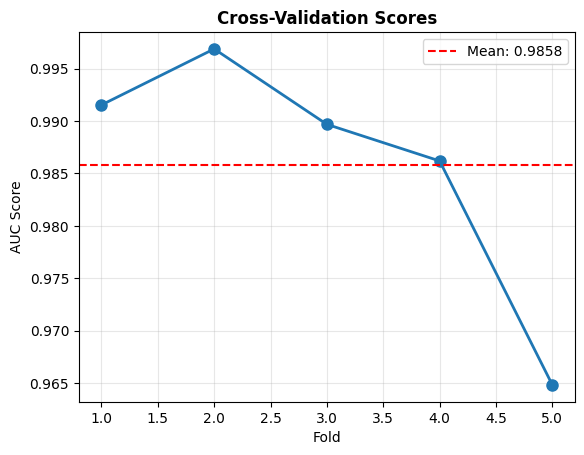

In [15]:
# Cross-validation scores
plt.subplot(1, 1, 1)
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('AUC Score')
plt.title('Cross-Validation Scores', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

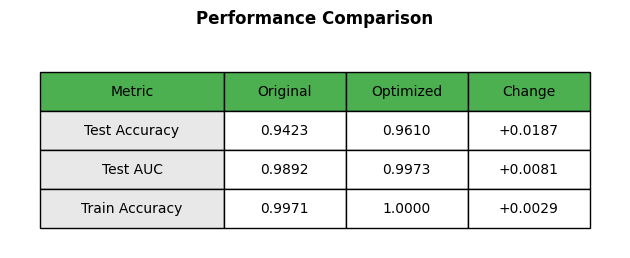

In [16]:
# Metrics comparison table
plt.subplot(2, 1, 2)
plt.axis('off')
metrics_comparison = [
    ['Metric', 'Original', 'Optimized', 'Change'],
    ['Test Accuracy', '0.9423', f'{test_accuracy:.4f}', f'{test_accuracy - 0.9423:+.4f}'],
    ['Test AUC', '0.9892', f'{test_auc:.4f}', f'{test_auc - 0.9892:+.4f}'],
    ['Train Accuracy', '0.9971', f'{train_accuracy:.4f}', f'{train_accuracy - 0.9971:+.4f}']
]
table = plt.table(cellText=metrics_comparison, cellLoc='center', loc='center',
                 colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(4):
    table[(i, 0)].set_facecolor('#E8E8E8')
table[(0, 0)].set_facecolor('#4CAF50')
table[(0, 1)].set_facecolor('#4CAF50')
table[(0, 2)].set_facecolor('#4CAF50')
table[(0, 3)].set_facecolor('#4CAF50')
plt.title('Performance Comparison', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [17]:
# Save the optimized model

with open("rf_model_optimized.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("random_search_results.pkl", "wb") as f:
    pickle.dump(random_search, f)

with open("grid_search_results.pkl", "wb") as f:
    pickle.dump(grid_search, f)
